# 05e — DepthFormer-RGB (Swin-Tiny + UPerNet + PPM)

**Paper**: Ma et al. — *DepthFormer: Depth-Enhanced Transformer Network for Semantic Segmentation of the Martian Surface from Rover Images*  
DOI: `10.1029/2024EA003812` — Earth and Space Science 12, e2024EA003812 (2025)  

**Variante implementada**: DepthFormer-**RGB** — sin canal de profundidad.  

**Justificación académica**: AI4MARS no dispone de depth maps. Esta variante replica exactamente la rama de ablación que el propio paper reporta en su Tabla 3 (`Swin Transformer base` vs `DepthFormer`), lo cual hace la comparación académicamente válida. El paper reporta que el Swin base (sin profundidad) obtiene mIoU=73.58 en DepthMars; nuestra implementación equivale funcionalmente a eso pero sobre AI4MARS.

**Arquitectura**:  
- **Encoder**: Swin-Tiny jerárquico con `img_size=256` (timm, pretrained) — sin interpolación posicional  
- **Decoder**: UPerNet inspirado en UPerNet (Xiao et al., 2018) con FPN top-down  
- **PPM**: Pyramid Pooling Module de PSPNet al final del encoder  
- **Input**: `[B, 3, 256, 256]` — sin canal de depth

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/ai4mars_DL-v3')
    sys.path.append(str(PROJECT_ROOT / 'notebooks'))
else:
    PROJECT_ROOT = Path.cwd().parent
    if not (PROJECT_ROOT / 'processed').exists():
        PROJECT_ROOT = Path.cwd().parent.parent

print(f'ROOT: {PROJECT_ROOT} | existe: {PROJECT_ROOT.exists()}')

ROOT: c:\Users\User\Documents\DeepLearning\ai4mars_DL-v3 | existe: True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from mars_utils import (
    set_seed, load_norm_stats, load_split,
    build_dataloaders,
    train_one_epoch, evaluate, train_model, run_multi_seed,
    append_benchmark_results, plot_best_seed_curves,
    print_summary_table, visualize_predictions, count_parameters,
    NUM_CLASSES, IGNORE_INDEX, SEEDS, BENCHMARK_CSV, CHECKPOINTS_DIR
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Configuración

In [3]:
MODEL_NAME   = 'DepthFormer-RGB'
FAST_SUBSET  = True   # ← True para prueba rápida, False para producción

LR           = 1e-4
WEIGHT_DECAY = 0.01
MAX_EPOCHS   = 80
PATIENCE     = 10
BATCH_SIZE   = 16

CLASS_WEIGHTS = torch.tensor([1.0, 0.8, 2.0, 8.0], dtype=torch.float32).to(DEVICE)

print(f'Modo: {"FAST SUBSET" if FAST_SUBSET else "PRODUCCIÓN"}')
print('Swin-Tiny con img_size=256 — sin interpolación posicional')

Modo: FAST SUBSET
Swin-Tiny con img_size=256 — sin interpolación posicional


## 2. Datos

In [4]:
df_train, df_val, df_gold = load_split()
mean, std = load_norm_stats()

# Bug 6 fix: derivar stem de image_path
train_ids = set(Path(p).stem for p in df_train['image_path'])
gold_ids  = set(Path(p).stem for p in df_gold['image_path'])
assert len(train_ids & gold_ids) == 0, '⚠️ DATA LEAKAGE detectado'
print(f'✅ Train: {len(df_train)} | Val: {len(df_val)} | Gold: {len(df_gold)}')
print(f'Normalización — mean: {mean} | std: {std}')

✅ Split cargado — train: 4200 | val: 1800 | gold test: 322
✅ Train: 4200 | Val: 1800 | Gold: 322
Normalización — mean: [0.2303263779898021, 0.2303263779898021, 0.2303263779898021] | std: [0.10591342097577364, 0.10591342097577364, 0.10591342097577364]


## 3. Arquitectura — DepthFormer-RGB

In [5]:
class PyramidPoolingModule(nn.Module):
    def __init__(self, in_channels: int, pool_sizes: tuple = (1, 2, 3, 6)):
        super().__init__()
        mid_ch = in_channels // len(pool_sizes)
        self.stages = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(size),
                nn.Conv2d(in_channels, mid_ch, 1, bias=False),
                nn.BatchNorm2d(mid_ch),
                nn.ReLU(inplace=True)
            ) for size in pool_sizes
        ])
        fused_ch = in_channels + mid_ch * len(pool_sizes)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(fused_ch, in_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        H, W = x.shape[-2:]
        parts = [x]
        for stage in self.stages:
            pooled = stage(x)
            parts.append(F.interpolate(pooled, size=(H, W), mode='bilinear', align_corners=False))
        return self.bottleneck(torch.cat(parts, dim=1))

In [6]:
class FPNDecoder(nn.Module):
    def __init__(self, in_channels_list: list, out_ch: int = 256):
        super().__init__()
        self.laterals = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
            ) for ch in in_channels_list
        ])
        self.smooths = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(out_ch * len(in_channels_list), out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )

    def forward(self, features: list):
        laterals = [lat(f) for lat, f in zip(self.laterals, features)]
        for i in range(len(laterals) - 2, -1, -1):
            laterals[i] = laterals[i] + F.interpolate(
                laterals[i+1], size=laterals[i].shape[-2:], mode='bilinear', align_corners=False
            )
        outs = [smooth(lat) for smooth, lat in zip(self.smooths, laterals)]
        target = outs[0].shape[-2:]
        outs_up = [F.interpolate(o, size=target, mode='bilinear', align_corners=False) for o in outs]
        return self.fuse(torch.cat(outs_up, dim=1))

In [7]:
class DepthFormerRGB(nn.Module):
    def __init__(self, num_classes: int = 4, img_size: int = 256):
        super().__init__()
        self.encoder = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3),
            img_size=img_size
        )
        enc_chs = [96, 192, 384, 768]
        self.ppm = PyramidPoolingModule(in_channels=enc_chs[-1])
        self.decoder = FPNDecoder(in_channels_list=enc_chs, out_ch=256)
        self.head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(128, num_classes, 1)
        )

    def forward(self, x):
        H, W = x.shape[-2:]
        raw_feats = self.encoder(x)
        feats = [f.permute(0, 3, 1, 2).contiguous() for f in raw_feats]
        feats[3] = self.ppm(feats[3])
        dec = self.decoder(feats)
        return F.interpolate(self.head(dec), size=(H, W), mode='bilinear', align_corners=False)


def build_model():
    return DepthFormerRGB(num_classes=NUM_CLASSES, img_size=256).to(DEVICE)


_m = build_model()
_m.eval()
with torch.no_grad():
    _x = torch.randn(2, 3, 256, 256).to(DEVICE)
    _out = _m(_x)
    print(f'Forward OK — salida: {_out.shape}')

n_params = count_parameters(_m)
print(f'Parámetros: {n_params:.2f}M (KB ref: ~31.58M)')
del _m, _x, _out

Forward OK — salida: torch.Size([2, 4, 256, 256])
Parámetros: 42.02M (KB ref: ~31.58M)


## 4. Loss, Optimizer y Scheduler

In [8]:
def criterion_fn():
    return nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, ignore_index=IGNORE_INDEX)

def optimizer_fn(params):
    return torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)

def scheduler_fn(optimizer):
    return torch.optim.lr_scheduler.PolynomialLR(optimizer, total_iters=MAX_EPOCHS, power=0.9)

print('✅ Loss: CrossEntropyLoss con weights [1.0, 0.8, 2.0, 8.0]')
print('  Optimizer: AdamW (lr=1e-4, wd=0.01)')
print('  Scheduler: PolynomialLR (power=0.9, 80 iters)')

✅ Loss: CrossEntropyLoss con weights [1.0, 0.8, 2.0, 8.0]
  Optimizer: AdamW (lr=1e-4, wd=0.01)
  Scheduler: PolynomialLR (power=0.9, 80 iters)


## 5. Entrenamiento Multi-Seed

In [10]:
summary = run_multi_seed(
    model_fn       = build_model,
    df_train       = df_train,
    df_val         = df_val,
    df_gold        = df_gold,
    criterion_fn   = criterion_fn,
    optimizer_fn   = optimizer_fn,
    scheduler_fn   = scheduler_fn,
    model_name     = MODEL_NAME,
    device         = DEVICE,
    num_epochs     = MAX_EPOCHS,
    patience       = PATIENCE,
    batch_size     = BATCH_SIZE,
    fast_subset    = FAST_SUBSET,
    n_train_fast   = 200,
    n_val_fast     = 50,
)

Progreso encontrado — seeds completados: {42, 123}

  Seed 42 ya completado — saltando

  Seed 123 ya completado — saltando

───────────────────────────────────────────────────────
  Seed 7 | DepthFormer-RGB
⚡ Subset rápido — train: 200 | val: 50
   (Para entrenamiento real usar df_train y df_val completos)
Checkpoint periódico encontrado — reanudando desde DepthFormer-RGB_seed7_periodic.pth
  Reanudando desde epoch 10 | best_miou: 0.7369 | epochs en historial: 9

  DepthFormer-RGB_seed7 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep  10/80 | loss=0.1687 mIoU=0.7845 | val_loss=0.3113 val_mIoU=0.6614 | rock=0.2040
Ep  11/80 | loss=0.1742 mIoU=0.7690 | val_loss=0.2840 val_mIoU=0.6973 | rock=0.3726
Ep  12/80 | loss=0.1774 mIoU=0.7654 | val_loss=0.2299 val_mIoU=0.7384 | rock=0.3041
Checkpoint periódico guardado (epoch 12)
Ep  13/80 | loss=0.1571 mIoU=0.8084 | val_loss=0.2916 val_mIoU=0.7081 | rock=0.2204
Ep  14/80 | loss=0.1293 mIoU=0.8174 | val_loss=0.2218 val_mIoU

## 6. Resultados Agregados

In [11]:
print_summary_table(summary)


  RESUMEN — DepthFormer-RGB
  Métrica                 Media       Std      IC95
  ------------------------------------------------
  mIoU                   0.7219    0.0290  ± 0.0328
  Pixel Accuracy         0.9554
  ------------------------------------------------
  IoU soil               0.9405    0.0183
  IoU bedrock            0.8960    0.0119
  IoU sand               0.8976    0.0324
  IoU big_rock           0.1535    0.0762
  ------------------------------------------------
  Params (M)           —
  Tiempo medio (s)          114
  Epoch mejor (mean)       16.0



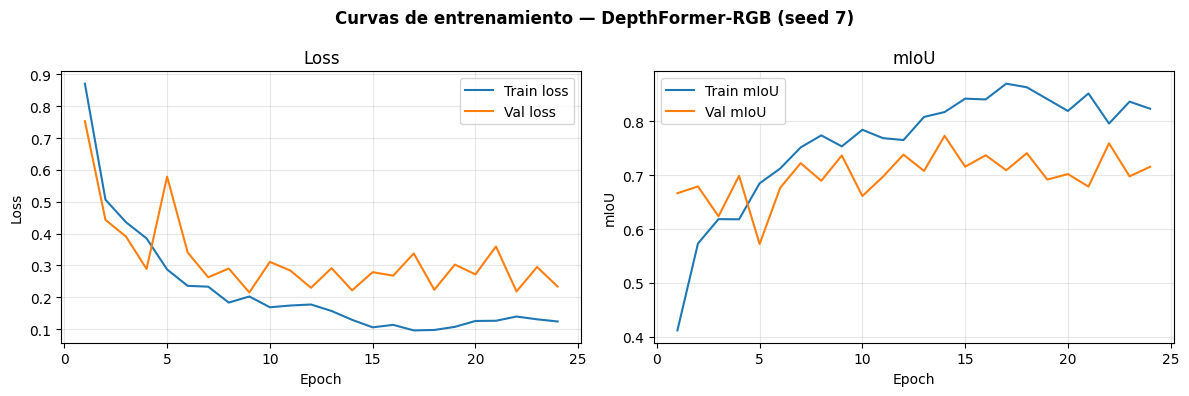

In [12]:
plot_best_seed_curves(summary)

In [13]:
# Bug 9 fix: limpiar fila anterior
if BENCHMARK_CSV.exists():
    df_csv = pd.read_csv(BENCHMARK_CSV)
    df_csv = df_csv[df_csv["model"] != MODEL_NAME]
    df_csv.to_csv(BENCHMARK_CSV, index=False)

params_M = count_parameters(build_model())
append_benchmark_results(summary, params_M=params_M)
print('✅ Guardado en benchmark_results.csv')

Resultados guardados en C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\results\benchmark_results.csv
✅ Guardado en benchmark_results.csv


## 7. Visualización Cualitativa

Mejor seed: 7 | mIoU gold: 0.7620


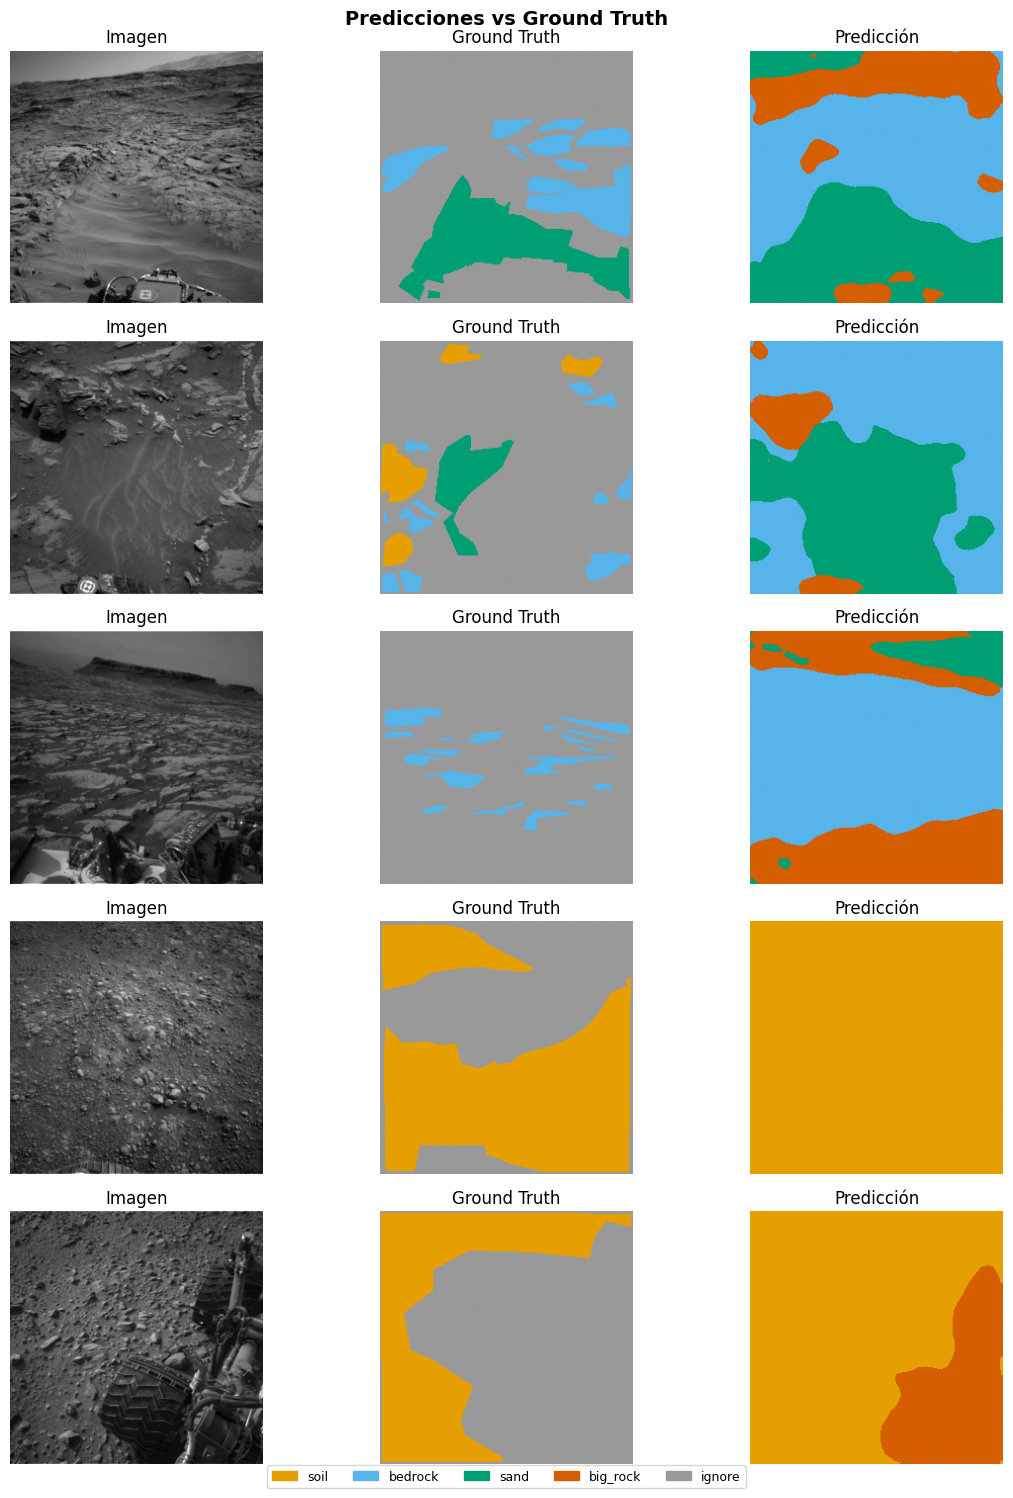

In [14]:
# Bug 8 fix: derivar best_seed manualmente
best_seed = max(summary["per_seed"], key=lambda r: r["mIoU"])["seed"]
best_miou = max(summary['per_seed'], key=lambda r: r['mIoU'])['mIoU']
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_seed{best_seed}_best.pth"

print(f"Mejor seed: {best_seed} | mIoU gold: {best_miou:.4f}")

best_model = build_model().to(DEVICE)
ckpt = torch.load(ckpt_path, map_location=DEVICE)
best_model.load_state_dict(ckpt["model_state"])
best_model.eval()

visualize_predictions(best_model, df_gold, DEVICE, mean=mean, std=std, n=5)

## 8. Nota sobre la variante RGB vs DepthFormer original

El paper original procesa inputs de 4 canales `[R, G, B, Depth]`. Esta implementación usa 3 canales `[R, G, B]` porque AI4MARS no provee depth maps.

| Aspecto | DepthFormer original | Esta implementación |
|---------|---------------------|--------------------|
| Input | [B, 4, H, W] | [B, 3, H, W] |
| Dataset | DepthMars (Zhurong) | AI4MARS (Curiosity) |
| mIoU reportado | 75.99% | — (en evaluación) |
| Ablación comparable | Swin base: 73.58% | Equivalente |

## 9. Resumen Final

| Campo | Valor |
|-------|-------|
| Modelo | DepthFormer-RGB |
| Paper | Ma et al., Earth and Space Science 12 (2025) |
| Encoder | Swin-Tiny (timm, img_size=256, pretrained) |
| Decoder | UPerNet + FPN top-down + PPM |
| Loss | CrossEntropyLoss con class weights |
| Optimizer | AdamW (lr=1e-4, wd=0.01) |
| Scheduler | PolynomialLR (power=0.9) |
| Referencia histórica (2.1k imgs) | mIoU = 0.7609 ± 0.0123 |

---
*Resultados del gold set exportados a `results/benchmark_results.csv`.*